# I) Imports

In [101]:
import MRzeroCore as mr0
import pypulseq as pp
import numpy as np
import matplotlib.pyplot as plt
import torch

# II) Load and Build a Dynamic Phantom

In [102]:
# Replace this line with your MRzero parameter file (.npz)
PHANTOM_URL = '../MRXCAT_default.npz'

In [103]:
phantom = mr0.VoxelGridPhantom.load(PHANTOM_URL)

VoxelGridPhantom
size = tensor([0.3000, 0.3000, 0.0050])


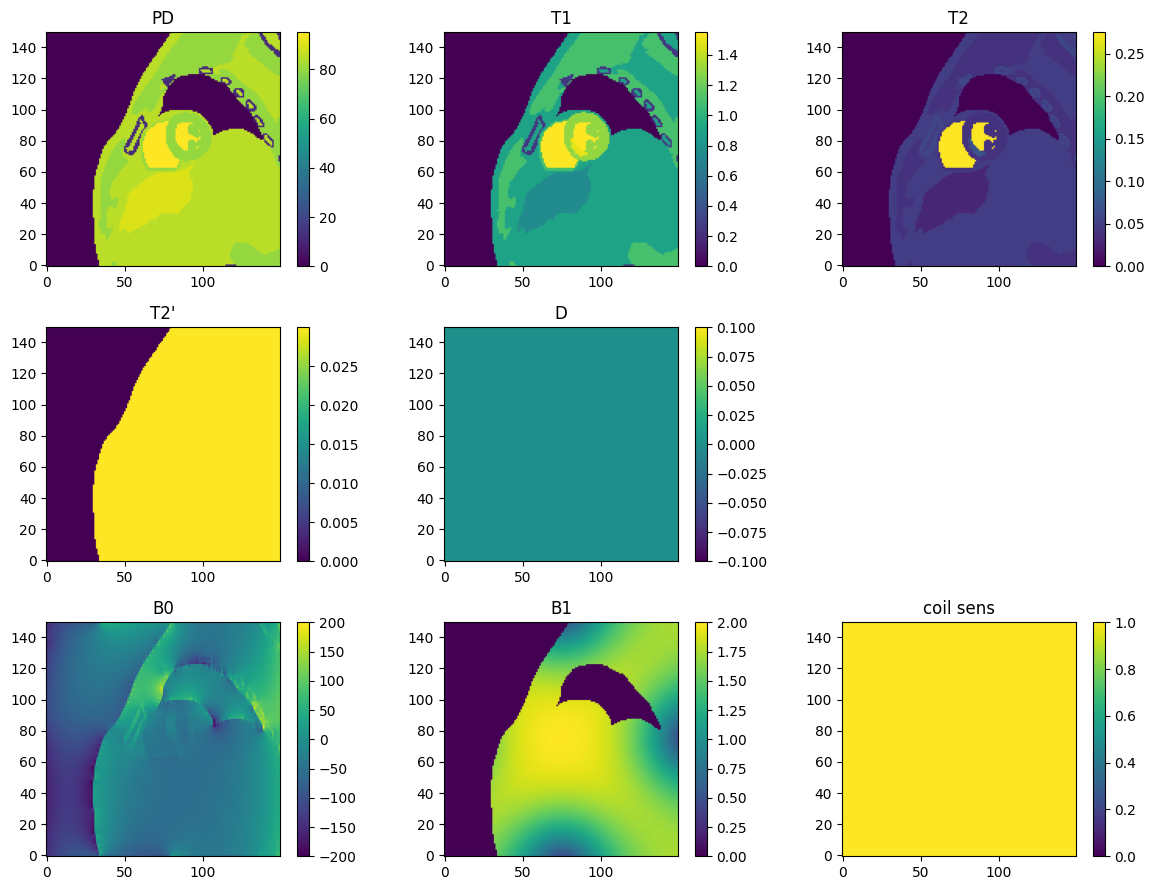

In [104]:
phantom.plot()

# III) Create a Segmented Flash 2D Sequence

In [118]:
# Create a sequence object
seq = pp.Sequence()

# System limits
system = pp.Opts()

# Sequence parameters
fov = 450e-3           # Field of view [m]
slice_thickness = 10e-3 # Slice thickness [m]
Nread = int(256*1.5)               # Frequency encoding steps
Nphase = 256               # Phase encoding steps
flip_angle = 15             # Flip angle [deg]
TE = 2e-3            # Echo time [s]
TI = 150e-3            # Inversion time [s]
dwell_time = 2e-5      # Dwell time [s]

# RF pulse and slice-selection gradient
rf_inv = pp.make_block_pulse(flip_angle=180 * np.pi / 180, duration=5e-3, system=system, )
rf_read = pp.make_sinc_pulse(
        flip_angle=flip_angle * np.pi / 180, duration=1e-3,
        slice_thickness=slice_thickness, apodization=0.5, time_bw_product=4,
        system=system, return_gz=False,
)

# Define other gradients and ADC events
gx = pp.make_trapezoid(channel='x', flat_area=Nread/fov, flat_time=Nread*dwell_time, system=system)
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area / 2, duration=1e-3, system=system)
adc = pp.make_adc(num_samples=Nread, duration=Nread*dwell_time, phase_offset=0 * np.pi/180, delay=gx.rise_time, system=system)
gx_spoil = pp.make_trapezoid(channel='x', area=1.5 * gx.area, duration=10e-3, system=system)

# Prephasing gradients
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area/2, duration=1e-3, system=system)

# Phase encoding steps (in y)
all_phenc = np.arange(-Nphase // 2, Nphase // 2, 1) / fov


seq.add_block(rf_inv)
# wait for the inversion time
seq.add_block(pp.make_delay(TI))

for area_ph in all_phenc:
    #
    # Add sequence block
    gy_pre = pp.make_trapezoid(channel='y', area=area_ph, duration=1e-3, system=system)
    gy_post = pp.make_trapezoid(channel='y', area=-gy_pre.area, duration=1e-3, system=system)
    seq.add_block(rf_read)
    seq.add_block(pp.make_delay(TE))
    seq.add_block(gx_pre, gy_pre)
    seq.add_block(gx, adc)
    seq.add_block(gx_spoil, gy_post)
        

seq_file = 'flash2D_ir.seq'
seq.write(seq_file)

'd2aa9a956494f23eef73c3e074817246'

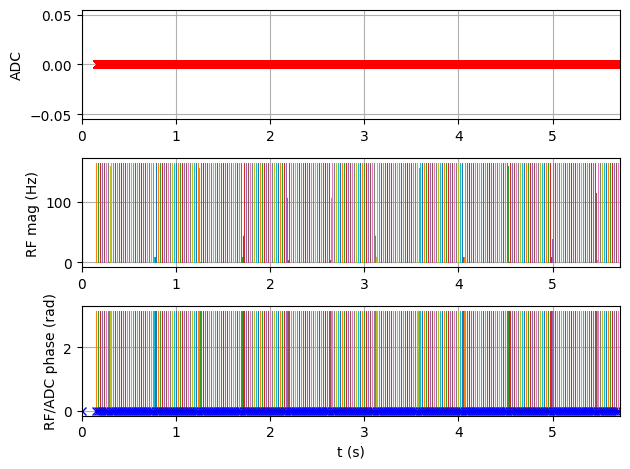

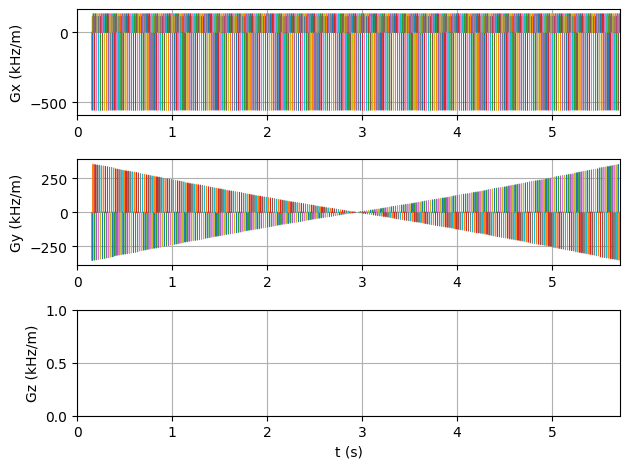

In [119]:
seq.plot()

# III) Simulate and visualize results

In [120]:
seq0 = mr0.Sequence.import_file(seq_file).cuda()
data = phantom.build().cuda()
graph = mr0.compute_graph(seq0, data, 1000, 1e-4)
sig = mr0.execute_graph(graph, seq0, data, 1e-4, 1e-4)

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.06125871 s
Compute Graph
Computing Graph: 0.045778185 s
Analyze Graph
Analyzing Graph: 0.000561401 s
Converting Rust -> Python: 0.005818859 s
<<<< Rust <<<<
Calculating repetition 257 / 257 - done


In [121]:
kspace = torch.reshape((sig), (Nphase, Nread, -1)).clone()

In [122]:
# fftshift
image = torch.fft.fftshift( torch.fft.ifftn( torch.fft.ifftshift(kspace.detach().cpu(), axis=[0,1]), axis=[0,1] ), axis=[0,1] )
image = torch.sqrt(torch.sum(image**2, -1))

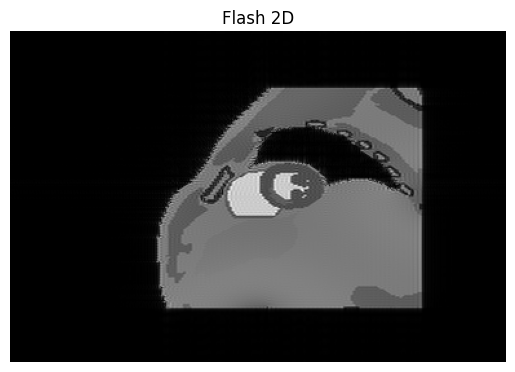

In [123]:
plt.imshow(torch.fliplr(image.abs()), cmap='gray')
plt.axis('off')
plt.title('Flash 2D')
plt.show()